# Data Prep to create Silver Parquet
Prerequisites

data_loader -> bronze_chicago_taxi_2024.parquet

In [1]:
import pandas as pd
import requests
from pathlib import Path
import duckdb
import polars as pl
import numpy as np
import geopandas as gpd
from shapely import wkt
from shapely.validation import make_valid

import h3
import matplotlib.pyplot as plt

from shapely.geometry import Polygon, MultiPolygon

from run_config import PATHS, PROCESSED_DIR, H3_RESOLUTION, START_DATE, END_DATE


# Bronze Paths
BRONZE_TAXI_PATH = PATHS.bronze_taxi_trips
BRONZE_WEATHER_PATH = PATHS.bronze_weatherdata
CENSUS_TRACTS_CSV_PATH = PATHS.raw_census_tracts
BRONZE_CENSUS_TRACTS_PATH = PATHS.bronze_census_tracts
BRONZE_COMMUNITY_AREAS_PATH = PATHS.bronze_community_areas

# Silver Paths
# Complete Community Area population; explicitly marked as unfiltered
SILVER_TAXI_COMMUNITY_UNFILTERED_PATH = PATHS.silver_taxi_community_areas_unfiltered
# Common comparison population: all use only trips with a pickup Census Tract
SILVER_TAXI_COMMUNITY_PATH = PATHS.silver_taxi_community_areas
SILVER_TAXI_CENSUS_PATH = PATHS.silver_taxi_census_tracts
SILVER_TAXI_HEXAGON_PATH = PATHS.silver_taxi_hexagon
SILVER_WEATHER_PATH = PATHS.silver_weatherdata
HEXAGON_PATH = PATHS.silver_hexagon
BOUNDARY_PATH = PATHS.silver_boundary
SILVER_CENSUS_TRACTS_PATH = PATHS.silver_census_tracts
SILVER_COMMUNITY_AREAS_PATH = PATHS.silver_community_areas

# Min and Max Timestamp
START_TS = START_DATE
END_TS = END_DATE

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print(f"Processed data directory: {PROCESSED_DIR}")
print(f"H3 resolution: {H3_RESOLUTION}")

Processed data directory: /Users/lennartjekel/dev/git/Group-3-AAA/data/full/processed_data
H3 resolution: 7


## Taxi Data

### Plausi Check

column_name                                                        check_name    n_rows     pct severity
                trip_miles                                               <= 0 1338256.0  8.6860     high -> Drop
              trip_seconds                                               <= 0  208815.0  1.3553     high -> Drop
                      fare                                               <= 0   39734.0  0.2579     high -> Drop
                trip_total                                               <= 0   37776.0  0.2452     high -> Drop
                      fare                                            is_null   31816.0  0.2065     high -> See null values
                trip_total                                            is_null   31816.0  0.2065     high -> See null values
              trip_seconds                                               > 6h    8822.0  0.0573     high -> Check via Miles and Fare
              trip_seconds                                            is_null    2936.0  0.0191     high -> See null values
                      fare                                             > 1000    1738.0  0.0113     high -> Check via Seconds and Fare
        trip_end_timestamp                                       parse_failed     345.0  0.0022     high -> Check what happened
                trip_miles                                        > 250 miles     140.0  0.0009     high -> Check via Seconds and Fare
                trip_miles                                            is_null     130.0  0.0008     high -> See null values
      trip_start_timestamp                           after_trip_end_timestamp     100.0  0.0006     high -> Check, but anyways just few
        trip_end_timestamp         not_after_start_when_trip_seconds_gt_15min      32.0  0.0002     high -> Check, but anyways just few
      trip_start_timestamp          not_before_end_when_trip_seconds_gt_15min      32.0  0.0002     high -> Check, but anyways just few
      dropoff_census_tract                                            is_null 8751654.0 56.8032     info
       pickup_census_tract                                            is_null 8547337.0 55.4771     info
              trip_seconds                           < timestamp_diff_seconds 7262520.0 47.1379   medium -> Check
                trip_total       fare + tips + tolls + extras mismatch > 0.01 6948990.0 45.1029   medium -> Check
    dropoff_community_area                                            is_null 1366538.0  8.8696   medium
 dropoff_centroid_latitude                                            is_null 1285413.0  8.3431   medium
 dropoff_centroid_location                                            is_null 1285413.0  8.3431   medium
dropoff_centroid_longitude                                            is_null 1285413.0  8.3431   medium
     pickup_community_area                                            is_null  429216.0  2.7859   medium
  pickup_centroid_latitude                                            is_null  421354.0  2.7348   medium
  pickup_centroid_location                                            is_null  421354.0  2.7348   medium
 pickup_centroid_longitude                                            is_null  421354.0  2.7348   medium
             fare_per_mile                                               > 50  200919.0  1.3041   medium
            total_per_mile                                              > 100  146833.0  0.9530   medium
                      tips                                    tip_rate > 100%   80542.0  0.5228   medium
                    extras                                            is_null   31816.0  0.2065   medium
                      tips                                            is_null   31816.0  0.2065   medium
                     tolls                                            is_null   31816.0  0.2065   medium
              trip_seconds                                               > 3h   14920.0  0.0968   medium
                       mph                                          > 100 mph    4607.0  0.0299   medium
                      fare                                              > 500    3304.0  0.0214   medium
                    extras                                              > 100    2078.0  0.0135   medium
                trip_total                                             > 1000    1791.0  0.0116   medium
                trip_miles                                        > 100 miles    1243.0  0.0081   medium
              trip_seconds abs(trip_seconds - timestamp_diff_seconds) > 15min     138.0  0.0009   medium
                     tolls                                              > 100      30.0  0.0002   medium
                      tips                                              > 200      11.0  0.0001   medium

In [2]:
# drop / filter conditions from plausi-check
# Assumptions what defines a valid trip in our understanding:
valid_trip_miles = (pl.col("trip_miles") > 0) & (pl.col("trip_miles") <= 250) # valid trip: 0 < trip_miles <= 250
valid_trip_seconds = (pl.col("trip_seconds") > 59) & (pl.col("trip_seconds") <= 10_800) # valid trip: 59 < trip_seconds < 10_800 (3 hours)
valid_trip_fare = (pl.col("fare") > 0) & (pl.col("fare") <= 500) # valid trip: 0 < fare <= 500
valid_trip_tips = (pl.col("tips") >= 0) & (pl.col("tips") <= 200) # valid trip: 0 <= tips <= 200
valid_trip_tolls = (pl.col("tolls") >= 0) & (pl.col("tolls") <= 100) # valid trip: 0 <= tolls <= 100
valid_trip_extras = (pl.col("extras") >= 0) & (pl.col("extras") <= 100) # valid trip: 0 <= extras <= 100
valid_trip_total = (pl.col("trip_total") > 0) & (pl.col("trip_total") <= 1_000) # valid trip: 0 < total <= 1,000

Drop columns and rows with null values, remove duplicates entirely

In [3]:
DROP_COLUMNS = [
    ":created_at", # meta data from API
    ":updated_at", # meta data from API
    ":version", # meta data from API
    ":id", # meta data from API
]

REQUIRED_NOT_NULL_COLUMNS = [
    "pickup_centroid_latitude",
    "pickup_centroid_longitude",
    "pickup_community_area" # very little number of not null (less than 2k)
    # dropoff can be null, because it is less important for demand 
]

UNIQUE_KEY = ["taxi_id", "trip_start_timestamp", "pickup_centroid_location"]

REQUIRED_NOT_NULL_COLUMNS = list(set(REQUIRED_NOT_NULL_COLUMNS + UNIQUE_KEY))

taxi_base = (
    pl.scan_parquet(BRONZE_TAXI_PATH)
    .drop(DROP_COLUMNS)
    .filter(
        (pl.col("trip_start_timestamp") >= pl.lit(START_TS).str.to_datetime())
        & (pl.col("trip_start_timestamp") < pl.lit(END_TS).str.to_datetime())
    )
    .filter(
        pl.all_horizontal([
            pl.col(col).is_not_null()
            for col in REQUIRED_NOT_NULL_COLUMNS
        ])
    )
)


# Determine duplicate keys on the three key columns only. The anti join removes
# every occurrence of a duplicated key without carrying a window column across
# the complete wide taxi dataset.
duplicate_taxi_keys = (
    taxi_base
    .select(UNIQUE_KEY)
    .group_by(UNIQUE_KEY)
    .len()
    .filter(pl.col("len") > 1)
    .select(UNIQUE_KEY)
)

taxi_silver = taxi_base.join(
    duplicate_taxi_keys,
    on=UNIQUE_KEY,
    how="anti",
)

In [4]:
# Use the same half-open interval as the loader: [START_DATE, END_DATE).
START_TAXI_TS = pd.Timestamp(START_TS)
END_TAXI_TS = pd.Timestamp(END_TS)

print(START_TAXI_TS)
print(END_TAXI_TS)

2024-01-01 00:00:00
2026-05-01 00:00:00


In [5]:
# Drop rows by conditions
taxi_silver = taxi_silver.filter(
    valid_trip_miles
    & valid_trip_seconds
    & valid_trip_fare
    & valid_trip_tips
    & valid_trip_tolls
    & valid_trip_extras
    & valid_trip_total 
)

### Add flag for location quality

According to the dataset description (https://data.cityofchicago.org/Transportation/Taxi-Trips-2024-/ajtu-isnz/about_data) the pickup coordinates are the centroid of the census tract if available and else of the community area. 

Therefore we create a flag that shows us if the pickup centroid is created of the census tract or community area.


In [6]:
taxi_silver = (
    taxi_silver
    .with_columns(
        pl.col("pickup_census_tract")
        .is_not_null()
        .cast(pl.Int8)
        .alias("pickup_from_census_tract")
    )
)

### Map pickup Census Tracts to the target dimension

Taxi Census IDs and the target Census polygons can use different boundary vintages. Each available source ID has one stable Census-based pickup centroid. A small centroid crosswalk therefore maps source IDs to the target `CENSUS_T_1` dimension. Trips without a source Census ID remain unmapped and are still excluded from all filtered comparison datasets.

In [7]:
# Build the target polygons from Bronze here so the mapping is available before
# the four taxi Silver datasets are written. The regular spatial-dimension cell
# below writes the same polygons to the configured Silver path.
target_census_raw = pd.read_parquet(BRONZE_CENSUS_TRACTS_PATH)
if "the_geom" not in target_census_raw.columns:
    raise ValueError(
        f"'the_geom' not found. Available columns: {list(target_census_raw.columns)}"
    )

target_census_raw["geometry"] = target_census_raw["the_geom"].apply(wkt.loads)
target_census_raw["geometry"] = target_census_raw["geometry"].apply(make_valid)
target_census = gpd.GeoDataFrame(
    target_census_raw[["CENSUS_T_1", "geometry"]].copy(),
    geometry="geometry",
    crs="EPSG:4326",
)

# Build the 469-row crosswalk from a narrow Bronze projection. This avoids
# executing the complete wide Silver pipeline merely to collect the centroids.
crosswalk_source_required = (
    pl.scan_parquet(BRONZE_TAXI_PATH)
    .filter(
        (pl.col("trip_start_timestamp") >= pl.lit(START_TS).str.to_datetime())
        & (pl.col("trip_start_timestamp") < pl.lit(END_TS).str.to_datetime())
    )
    .filter(
        pl.all_horizontal([
            pl.col(col).is_not_null()
            for col in REQUIRED_NOT_NULL_COLUMNS
        ])
    )
)
duplicate_crosswalk_keys = (
    crosswalk_source_required
    .select(UNIQUE_KEY)
    .group_by(UNIQUE_KEY)
    .len()
    .filter(pl.col("len") > 1)
    .select(UNIQUE_KEY)
)

crosswalk_source_valid = (
    crosswalk_source_required
    .filter(
        valid_trip_miles
        & valid_trip_seconds
        & valid_trip_fare
        & valid_trip_tips
        & valid_trip_tolls
        & valid_trip_extras
        & valid_trip_total
        & pl.col("pickup_census_tract").is_not_null()
    )
    .select([
        *UNIQUE_KEY,
        "pickup_census_tract",
        "pickup_centroid_latitude",
        "pickup_centroid_longitude",
    ])
)

# One row per source ID is sufficient: profiling confirmed that every available
# pickup Census source ID has exactly one stable centroid coordinate.
source_census_centroids = (
    crosswalk_source_valid
    .join(duplicate_crosswalk_keys, on=UNIQUE_KEY, how="anti")
    .select([
        "pickup_census_tract",
        "pickup_centroid_latitude",
        "pickup_centroid_longitude",
    ])
    .unique()
    .collect()
    .to_pandas()
)

coords_per_source = source_census_centroids.groupby("pickup_census_tract").size()
if not coords_per_source.eq(1).all():
    raise ValueError("A pickup Census source ID maps to multiple centroid coordinates")

source_census_points = gpd.GeoDataFrame(
    source_census_centroids,
    geometry=gpd.points_from_xy(
        source_census_centroids["pickup_centroid_longitude"],
        source_census_centroids["pickup_centroid_latitude"],
    ),
    crs="EPSG:4326",
)

census_crosswalk_gdf = gpd.sjoin(
    source_census_points,
    target_census[["CENSUS_T_1", "geometry"]],
    how="left",
    predicate="within",
)

if census_crosswalk_gdf["CENSUS_T_1"].isna().any():
    missing = census_crosswalk_gdf.loc[
        census_crosswalk_gdf["CENSUS_T_1"].isna(), "pickup_census_tract"
    ].tolist()
    raise ValueError(f"Census centroid mapping failed for source IDs: {missing}")
if census_crosswalk_gdf["pickup_census_tract"].duplicated().any():
    raise ValueError("A pickup Census source ID maps to multiple target polygons")

census_crosswalk = pl.from_pandas(
    census_crosswalk_gdf[["pickup_census_tract", "CENSUS_T_1"]]
    .rename(columns={
        "pickup_census_tract": "pickup_census_tract_source",
        "CENSUS_T_1": "pickup_census_tract_canonical",
    })
    .astype({
        "pickup_census_tract_source": "int64",
        "pickup_census_tract_canonical": "int64",
    })
)

taxi_silver = (
    taxi_silver
    .rename({"pickup_census_tract": "pickup_census_tract_source"})
    .join(census_crosswalk.lazy(), on="pickup_census_tract_source", how="left")
    .with_columns([
        pl.col("pickup_census_tract_canonical").alias("pickup_census_tract"),
        pl.when(pl.col("pickup_census_tract_source").is_null())
        .then(pl.lit("missing_source_id"))
        .when(
            pl.col("pickup_census_tract_source")
            == pl.col("pickup_census_tract_canonical")
        )
        .then(pl.lit("source_id_matches_dimension"))
        .otherwise(pl.lit("centroid_crosswalk"))
        .alias("pickup_census_mapping_method"),
    ])
)

print(census_crosswalk)

shape: (469, 2)
┌────────────────────────────┬───────────────────────────────┐
│ pickup_census_tract_source ┆ pickup_census_tract_canonical │
│ ---                        ┆ ---                           │
│ i64                        ┆ i64                           │
╞════════════════════════════╪═══════════════════════════════╡
│ 17031832900                ┆ 17031282400                   │
│ 17031280900                ┆ 17031280900                   │
│ 17031839200                ┆ 17031350300                   │
│ 17031561000                ┆ 17031561000                   │
│ 17031431301                ┆ 17031431300                   │
│ …                          ┆ …                             │
│ 17031070400                ┆ 17031070400                   │
│ 17031500200                ┆ 17031500200                   │
│ 17031100600                ┆ 17031100600                   │
│ 17031030702                ┆ 17031030700                   │
│ 17031020902                ┆ 17031020

### Save spatial comparison versions

The complete dataset remains available for Community Area analyses. For a fair comparison across Community Areas, Census Tracts and H3, three additional datasets contain the identical subset of trips with a non-null `pickup_census_tract`.

In [8]:
from shutil import copyfile

# Materialize the expensive common pipeline exactly once.
taxi_silver.sink_parquet(SILVER_TAXI_COMMUNITY_UNFILTERED_PATH)
print(
    "Silver taxi dataset 'community_areas_unfiltered' written to: "
    f"{SILVER_TAXI_COMMUNITY_UNFILTERED_PATH}"
)

# Re-scan the materialized result. The duplicate check, plausibility filters and
# Census mapping are therefore not recomputed for every filtered output.
taxi_silver_materialized = pl.scan_parquet(SILVER_TAXI_COMMUNITY_UNFILTERED_PATH)
print(
    taxi_silver_materialized
    .group_by("pickup_census_mapping_method")
    .len()
    .collect()
    .sort("pickup_census_mapping_method")
)

# Compute and write the identical filtered population only once.
taxi_with_pickup_census_tract = taxi_silver_materialized.filter(
    pl.col("pickup_census_tract_source").is_not_null()
    & pl.col("pickup_census_tract").is_not_null()
)
taxi_with_pickup_census_tract.sink_parquet(
    SILVER_TAXI_COMMUNITY_PATH
)

# Census, H3 and filtered Community Area require exactly the same rows and
# schema. File copies avoid two further scans and Parquet encodes.
copyfile(
    SILVER_TAXI_COMMUNITY_PATH,
    SILVER_TAXI_CENSUS_PATH,
)
copyfile(
    SILVER_TAXI_COMMUNITY_PATH,
    SILVER_TAXI_HEXAGON_PATH,
)

silver_taxi_outputs = {
    "community_areas_unfiltered": SILVER_TAXI_COMMUNITY_UNFILTERED_PATH,
    "community_areas": SILVER_TAXI_COMMUNITY_PATH,
    "census_tracts": SILVER_TAXI_CENSUS_PATH,
    f"hexagon_{H3_RESOLUTION}": SILVER_TAXI_HEXAGON_PATH,
}

for dataset_name, output_path in silver_taxi_outputs.items():
    print(f"Silver taxi dataset '{dataset_name}' available at: {output_path}")

Silver taxi dataset 'community_areas_unfiltered' written to: /Users/lennartjekel/dev/git/Group-3-AAA/data/full/processed_data/silver_taxi_community_areas_UNFILTERED.parquet
shape: (3, 2)
┌──────────────────────────────┬─────────┐
│ pickup_census_mapping_method ┆ len     │
│ ---                          ┆ ---     │
│ str                          ┆ u32     │
╞══════════════════════════════╪═════════╡
│ centroid_crosswalk           ┆ 3218779 │
│ missing_source_id            ┆ 7337271 │
│ source_id_matches_dimension  ┆ 2830656 │
└──────────────────────────────┴─────────┘
Silver taxi dataset 'community_areas_unfiltered' available at: /Users/lennartjekel/dev/git/Group-3-AAA/data/full/processed_data/silver_taxi_community_areas_UNFILTERED.parquet
Silver taxi dataset 'community_areas' available at: /Users/lennartjekel/dev/git/Group-3-AAA/data/full/processed_data/silver_taxi_community_areas.parquet
Silver taxi dataset 'census_tracts' available at: /Users/lennartjekel/dev/git/Group-3-AAA/data/ful

In [9]:
silver_output_quality = []

for dataset_name, output_path in silver_taxi_outputs.items():
    quality = (
        pl.scan_parquet(output_path)
        .select([
            pl.len().alias("rows"),
            pl.col("pickup_census_tract_source").null_count().alias("missing_source_census_tract"),
            pl.col("pickup_census_tract").null_count().alias("missing_mapped_census_tract"),
        ])
        .collect()
        .with_columns(pl.lit(dataset_name).alias("dataset"))
        .select([
            "dataset",
            "rows",
            "missing_source_census_tract",
            "missing_mapped_census_tract",
        ])
    )
    silver_output_quality.append(quality)

silver_output_quality = pl.concat(silver_output_quality)
print(silver_output_quality)

assert (
    silver_output_quality
    .filter(pl.col("dataset") != "community_areas_unfiltered")
    .select([
        pl.col("missing_source_census_tract").sum(),
        pl.col("missing_mapped_census_tract").sum(),
    ])
    .row(0)
    == (0, 0)
)

shape: (4, 4)
┌────────────────────────────┬──────────┬─────────────────────────────┬────────────────────────────┐
│ dataset                    ┆ rows     ┆ missing_source_census_tract ┆ missing_mapped_census_trac │
│ ---                        ┆ ---      ┆ ---                         ┆ t                          │
│ str                        ┆ u32      ┆ u32                         ┆ ---                        │
│                            ┆          ┆                             ┆ u32                        │
╞════════════════════════════╪══════════╪═════════════════════════════╪════════════════════════════╡
│ community_areas_unfiltered ┆ 13386706 ┆ 7337271                     ┆ 7337271                    │
│ community_areas            ┆ 6049435  ┆ 0                           ┆ 0                          │
│ census_tracts              ┆ 6049435  ┆ 0                           ┆ 0                          │
│ hexagon_7                  ┆ 6049435  ┆ 0                           ┆ 0    

### Null Values

column_name                 n_rows   n_nulls  null_pct
      dropoff_census_tract 15406960 8751654.0     56.80 -> Ok, might be estimated via drop off location or anyways not needed because of hexagon structure
       pickup_census_tract 15406960 8547337.0     55.48 -> Ok, might be estimated via drop off location or anyways not needed because of hexagon structure
    dropoff_community_area 15406960 1366538.0      8.87 -> Ok, might be estimated via drop off location or anyways not needed because of hexagon structure
 dropoff_centroid_location 15406960 1285413.0      8.34 -> Ok, pickup for demand more important and dropoff not
 dropoff_centroid_latitude 15406960 1285413.0      8.34 -> Ok, pickup for demand more important and dropoff not
dropoff_centroid_longitude 15406960 1285413.0      8.34 -> Ok, pickup for demand more important and dropoff not
     pickup_community_area 15406960  429216.0      2.79 -> Ok, might be estimated via drop off location or anyways not needed because of hexagon structure
  pickup_centroid_latitude 15406960  421354.0      2.73 -> drop, only very few might be estimated based on census_tract 
 pickup_centroid_longitude 15406960  421354.0      2.73 -> drop, only very few might be estimated based on census_tract 
  pickup_centroid_location 15406960  421354.0      2.73 -> -> drop, only very few might be estimated based on census_tract 
                      fare 15406960   31816.0      0.21 -> Estimate, average fare for "trip_seconds" or more precise some range of it
                      tips 15406960   31816.0      0.21 -> Estimate, average tips for "trip_seconds" or more precise some range of it
                     tolls 15406960   31816.0      0.21 -> Estimate, average tolls for "trip_seconds" or more precise some range of it
                    extras 15406960   31816.0      0.21 -> Estimate, average extras for "trip_seconds" or more precise some range of it
                trip_total 15406960   31816.0      0.21 -> Estimate, sum of fare, tips, tolls, extras
              trip_seconds 15406960    2936.0      0.02 -> Estimate, "trip_end_timestamp" - "trip_start_timestamp" (if both are not null)
                   trip_id 15406960       0.0      0.00 -> Ok
                   taxi_id 15406960       0.0      0.00 -> Ok
      trip_start_timestamp 15406960       0.0      0.00 -> Ok
        trip_end_timestamp 15406960     345.0      0.00 -> Estimate, "trip_start_timestamp" + "trip_seconds" (if "trip_seconds" not null)
                trip_miles 15406960     130.0      0.00 -> Estimate, average trip_miles for "trip_seconds" or more precise some range of it
               :created_at 15406960       0.0      0.00 -> Ok, drop anyways
               :updated_at 15406960       0.0      0.00 -> Ok, drop anyways
                  :version 15406960       0.0      0.00 -> Ok, drop anyways
              payment_type 15406960       0.0      0.00 -> Ok
                   company 15406960       0.0      0.00 -> Ok
                       :id 15406960       0.0      0.00 -> Ok, drop anyways

### Quality Check

In [10]:
duckdb.sql(f"""
    SELECT COUNT(*)
    FROM read_parquet('{SILVER_TAXI_COMMUNITY_UNFILTERED_PATH}')  
""").show()

con = duckdb.connect()

columns = con.sql(f"""
DESCRIBE SELECT *
FROM read_parquet('{SILVER_TAXI_COMMUNITY_UNFILTERED_PATH}')
""").df()["column_name"].tolist()

parts = []

for col in columns:
    parts.append(f"""
    SELECT
        '{col}' AS column_name,
        COUNT(*) AS n_rows,
        SUM(CASE WHEN "{col}" IS NULL THEN 1 ELSE 0 END) AS n_nulls,
        ROUND(
            100.0 * SUM(CASE WHEN "{col}" IS NULL THEN 1 ELSE 0 END) / COUNT(*),
            2
        ) AS null_pct
    FROM read_parquet('{SILVER_TAXI_COMMUNITY_UNFILTERED_PATH}')
    """)

query = "\nUNION ALL\n".join(parts) + "\nORDER BY null_pct DESC"

null_report = con.sql(query).df()
print(null_report.to_string(index=False))

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│     13386706 │
└──────────────┘

                  column_name   n_rows   n_nulls  null_pct
         dropoff_census_tract 13386706 7541128.0     56.33
          pickup_census_tract 13386706 7337271.0     54.81
pickup_census_tract_canonical 13386706 7337271.0     54.81
   pickup_census_tract_source 13386706 7337271.0     54.81
       dropoff_community_area 13386706 1010238.0      7.55
    dropoff_centroid_location 13386706  939762.0      7.02
   dropoff_centroid_longitude 13386706  939762.0      7.02
    dropoff_centroid_latitude 13386706  939762.0      7.02
                      taxi_id 13386706       0.0      0.00
        pickup_community_area 13386706       0.0      0.00
                         fare 13386706       0.0      0.00
                         tips 13386706       0.0      0.00
                        tolls 13386706       0.0      0.00
                       extras 13386706       0.0      0.00
            

In [11]:
duckdb.sql(f"""
    SELECT distinct pickup_centroid_latitude, pickup_centroid_longitude
    FROM read_parquet('{SILVER_TAXI_COMMUNITY_UNFILTERED_PATH}')  
    WHERE pickup_census_tract is null      
""").show()

duckdb.sql(f"""
    SELECT distinct dropoff_centroid_latitude, dropoff_centroid_longitude
    FROM read_parquet('{SILVER_TAXI_COMMUNITY_UNFILTERED_PATH}')  
    WHERE dropoff_census_tract is null      
""").show()

┌──────────────────────────┬───────────────────────────┐
│ pickup_centroid_latitude │ pickup_centroid_longitude │
│          double          │          double           │
├──────────────────────────┼───────────────────────────┤
│             41.975170943 │             -87.687515515 │
│             41.980264315 │             -87.913624596 │
│             41.900069603 │             -87.720918238 │
│                41.968069 │             -87.721559063 │
│             41.978829526 │             -87.771166703 │
│             41.729676423 │             -87.572717134 │
│             41.769778059 │             -87.726929842 │
│               41.9867118 │             -87.663416405 │
│             41.850266366 │             -87.667569312 │
│             41.690633347 │             -87.570058269 │
│                   ·      │                   ·       │
│                   ·      │                   ·       │
│                   ·      │                   ·       │
│             41.835117986 │   

In [12]:
duckdb.sql(f"""
SELECT
    COUNT(*) AS n_rows,
    COUNT(DISTINCT trip_id) AS distinct_trip_id,
    COUNT(*) - COUNT(DISTINCT trip_id) AS duplicate_trip_id,

    COUNT(DISTINCT (taxi_id, trip_start_timestamp)) AS distinct_taxi_time_key,
    COUNT(*) - COUNT(DISTINCT (taxi_id, trip_start_timestamp)) AS duplicate_taxi_time_key,
    
    COUNT(DISTINCT (taxi_id, trip_start_timestamp, pickup_centroid_location)) AS distinct_taxi_time_pickup_key,
    COUNT(*) - COUNT(DISTINCT (taxi_id, trip_start_timestamp, pickup_centroid_location)) AS duplicate_taxi_time_pickup_key
FROM read_parquet('{SILVER_TAXI_COMMUNITY_UNFILTERED_PATH}')
""").show(max_width=500)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────┬──────────────────┬───────────────────┬────────────────────────┬─────────────────────────┬───────────────────────────────┬────────────────────────────────┐
│  n_rows  │ distinct_trip_id │ duplicate_trip_id │ distinct_taxi_time_key │ duplicate_taxi_time_key │ distinct_taxi_time_pickup_key │ duplicate_taxi_time_pickup_key │
│  int64   │      int64       │       int64       │         int64          │          int64          │             int64             │             int64              │
├──────────┼──────────────────┼───────────────────┼────────────────────────┼─────────────────────────┼───────────────────────────────┼────────────────────────────────┤
│ 13386706 │         13386706 │                 0 │               13098780 │                  287926 │                      13386706 │                              0 │
└──────────┴──────────────────┴───────────────────┴────────────────────────┴─────────────────────────┴───────────────────────────────┴──────────────────────────

## Weather Data

### Null Values
column_name  n_rows  n_nulls  null_pct
       gust   24360  18401.0     75.54 -> drop, too many missing values and likely no value add as wind speed is available
      skyc3   24360  18227.0     74.82 -> drop, too many missing values and likely no value add as cloud cover level 1 is available
      skyc2   24360  11411.0     46.84 -> drop, too many missing values and likely no value add as cloud cover level 1 is available
       p01m   24360      3.0      0.01 -> interpolate
       relh   24360      2.0      0.01 -> interpolate
       tmpc   24360      2.0      0.01 -> interpolate
    station   24360      0.0      0.00 -> Ok
      skyc1   24360      0.0      0.00 -> Ok
        lon   24360      0.0      0.00 -> Ok
      valid   24360      0.0      0.00 -> Ok
       vsby   24360      0.0      0.00 -> Ok
       sknt   24360      1.0      0.00 -> interpolate
        lat   24360      0.0      0.00 -> Ok

In [13]:
bronze_weather = pd.read_parquet(BRONZE_WEATHER_PATH)

# Filter weather data to include only rows within the min and max timestamp of taxi data
bronze_weather["valid"] = pd.to_datetime(bronze_weather["valid"])

bronze_weather_filtered = bronze_weather.loc[
    (bronze_weather["valid"] >= START_TAXI_TS) &
    (bronze_weather["valid"] < END_TAXI_TS)
].copy()

bronze_weather_filtered.to_parquet(
    SILVER_WEATHER_PATH,
    index=False,
)

## Chicago Census Tracts

In [14]:
# 1. Normales Parquet einlesen
census_tracts_raw = pd.read_parquet(BRONZE_CENSUS_TRACTS_PATH)

# 2. Prüfen, ob die Geometrie-Spalte vorhanden ist
if "the_geom" not in census_tracts_raw.columns:
    raise ValueError(
        f"'the_geom' not found. Available columns: {list(census_tracts_raw.columns)}"
    )

# 3. WKT-Multipolygon aus `the_geom` in echte Shapely-Geometrie umwandeln
census_tracts_raw["geometry"] = census_tracts_raw["the_geom"].apply(wkt.loads)

# 4. Optional: Geometrien reparieren, falls einzelne Polygone ungültig sind
census_tracts_raw["geometry"] = census_tracts_raw["geometry"].apply(make_valid)

# 5. GeoDataFrame bauen
census_tracts = gpd.GeoDataFrame(
    census_tracts_raw,
    geometry="geometry",
    crs="EPSG:4326",
)

# 6. Wichtige ID-Spalte als String halten, damit Joins später stabil sind
if "CENSUS_T_1" in census_tracts.columns:
    census_tracts["CENSUS_T_1"] = census_tracts["CENSUS_T_1"].astype(str)

# 7. Optional: ursprüngliche `the_geom`-Textspalte entfernen,
# weil `geometry` jetzt die echte Geo-Spalte ist
census_tracts = census_tracts.drop(columns=["the_geom"])


census_tracts.to_parquet(
    SILVER_CENSUS_TRACTS_PATH,
    index=False,
)

print(f"Written GeoParquet to: {SILVER_CENSUS_TRACTS_PATH}")
print(f"Rows: {len(census_tracts):,}")
print(f"CRS: {census_tracts.crs}")
print(census_tracts[["CENSUS_T_1", "geometry"]].head())

Written GeoParquet to: /Users/lennartjekel/dev/git/Group-3-AAA/data/full/processed_data/silver_census_tracts.geoparquet
Rows: 878
CRS: EPSG:4326
    CENSUS_T_1                                           geometry
0  17031720500  MULTIPOLYGON (((-87.69149 41.70636, -87.69148 ...
1  17031730200  MULTIPOLYGON (((-87.64651 41.73253, -87.64656 ...
2  17031730300  MULTIPOLYGON (((-87.66333 41.7212, -87.66345 4...
3  17031740100  MULTIPOLYGON (((-87.69646 41.70714, -87.69644 ...
4  17031710500  MULTIPOLYGON (((-87.66339 41.74848, -87.66335 ...


## Chicago Community Tracts

In [15]:
GEOMETRY_SOURCE_COL = "the_geom"


# 1. Normales Parquet einlesen
community_areas_raw = pd.read_parquet(BRONZE_COMMUNITY_AREAS_PATH)

# 2. Prüfen, ob die Geometrie-Spalte vorhanden ist
if GEOMETRY_SOURCE_COL not in community_areas_raw.columns:
    raise ValueError(
        f"'{GEOMETRY_SOURCE_COL}' not found. "
        f"Available columns: {list(community_areas_raw.columns)}"
    )

# 3. WKT-Multipolygon aus `the_gom` in echte Shapely-Geometrie umwandeln
community_areas_raw["geometry"] = community_areas_raw[GEOMETRY_SOURCE_COL].apply(wkt.loads)

# 4. Optional: ungültige Geometrien reparieren
community_areas_raw["geometry"] = community_areas_raw["geometry"].apply(make_valid)

# 5. GeoDataFrame bauen
community_areas = gpd.GeoDataFrame(
    community_areas_raw,
    geometry="geometry",
    crs="EPSG:4326",
)

# 6. Wichtige ID-Spalten stabil als String halten, falls vorhanden
possible_key_columns = [
    "community_area",
    "community",
    "area_num_1",
    "AREA_NUM_1",
    "area_numbe",
    "AREA_NUMBE",
]

for col in possible_key_columns:
    if col in community_areas.columns:
        community_areas[col] = community_areas[col].astype(str)

# 7. Ursprüngliche WKT-Textspalte entfernen
community_areas = community_areas.drop(columns=[GEOMETRY_SOURCE_COL])


community_areas.to_parquet(
    SILVER_COMMUNITY_AREAS_PATH,
    index=False,
)

print(f"Written GeoParquet to: {SILVER_COMMUNITY_AREAS_PATH}")
print(f"Rows: {len(community_areas):,}")
print(f"CRS: {community_areas.crs}")
print(community_areas.head())

Written GeoParquet to: /Users/lennartjekel/dev/git/Group-3-AAA/data/full/processed_data/silver_community_areas.geoparquet
Rows: 77
CRS: EPSG:4326
  AREA_NUMBE       COMMUNITY AREA_NUM_1       SHAPE_AREA       SHAPE_LEN  \
0          1     ROGERS PARK          1  51,259,902.4506  34,052.3975757   
1          2      WEST RIDGE          2  98,429,094.8621  43,020.6894583   
2          3          UPTOWN          3  65,095,642.7289  46,972.7945549   
3          4  LINCOLN SQUARE          4  71,352,328.2399  36,624.6030848   
4          5    NORTH CENTER          5    57,054,167.85  31,391.6697542   

                                            geometry  
0  MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ...  
1  MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ...  
2  MULTIPOLYGON (((-87.64102 41.9548, -87.644 41....  
3  MULTIPOLYGON (((-87.67441 41.9761, -87.6744 41...  
4  MULTIPOLYGON (((-87.67336 41.93234, -87.67342 ...  


## Chicago Hexagon

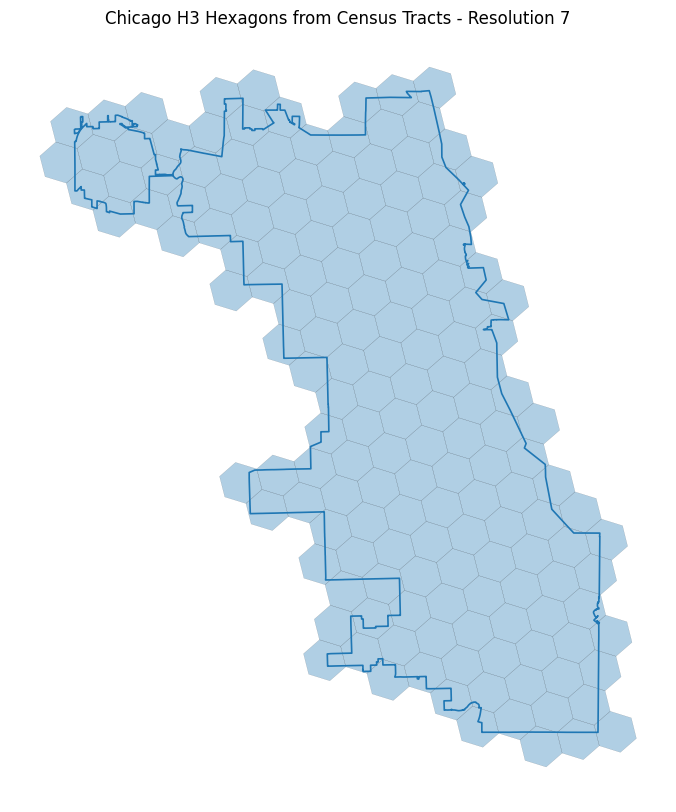

Census tracts: 878
H3 hexagons: 163


In [16]:
census_tracts_raw = pl.read_parquet(BRONZE_CENSUS_TRACTS_PATH)

census_tracts_raw = census_tracts_raw.with_columns(
    pl.col("the_geom").map_elements(wkt.loads, return_dtype=pl.Object)
)

census_tracts = gpd.GeoDataFrame(
    census_tracts_raw.to_pandas(),
    geometry="the_geom",
    crs="EPSG:4326",
)

chicago_boundary_geom = census_tracts.geometry.union_all()

chicago_boundary = gpd.GeoDataFrame(
    {"name": ["Chicago"]},
    geometry=[chicago_boundary_geom],
    crs="EPSG:4326",
)

def shapely_polygon_to_h3_cells(geom, resolution: int) -> set[str]:
    """
    Convert a Shapely Polygon or MultiPolygon to all overlapping H3 cell IDs.
    Including partially overlapping cells prevents valid Chicago boundary
    coordinates from being dropped when a cell center lies outside the city.
    Assumes geom is in EPSG:4326.
    """

    def polygon_to_latlngpoly(poly: Polygon) -> h3.LatLngPoly:
        # Shapely: (lon, lat)
        # H3:      (lat, lon)
        exterior = [(lat, lon) for lon, lat in poly.exterior.coords]

        holes = [
            [(lat, lon) for lon, lat in interior.coords]
            for interior in poly.interiors
        ]

        return h3.LatLngPoly(exterior, *holes)

    if isinstance(geom, Polygon):
        h3_poly = polygon_to_latlngpoly(geom)
        return set(
            h3.h3shape_to_cells_experimental(
                h3_poly,
                resolution,
                contain="overlap",
            )
        )

    if isinstance(geom, MultiPolygon):
        cells = set()

        for poly in geom.geoms:
            h3_poly = polygon_to_latlngpoly(poly)
            cells.update(
                h3.h3shape_to_cells_experimental(
                    h3_poly,
                    resolution,
                    contain="overlap",
                )
            )

        return cells

    raise TypeError(f"Unsupported geometry type: {geom.geom_type}")

chicago_h3_cells = shapely_polygon_to_h3_cells(
    chicago_boundary_geom,
    H3_RESOLUTION,
)

def h3_cell_to_polygon(cell: str) -> Polygon:
    # H3 gibt (lat, lon), Shapely braucht (lon, lat)
    boundary = h3.cell_to_boundary(cell)
    return Polygon([(lon, lat) for lat, lon in boundary])

hexagons = gpd.GeoDataFrame(
    {
        "h3_cell": list(chicago_h3_cells),
        "h3_resolution": H3_RESOLUTION,
    },
    geometry=[
        h3_cell_to_polygon(cell)
        for cell in chicago_h3_cells
    ],
    crs="EPSG:4326",
)

hexagons = hexagons.sort_values("h3_cell").reset_index(drop=True)

hexagons.to_parquet(HEXAGON_PATH)
chicago_boundary.to_parquet(BOUNDARY_PATH)

fig, ax = plt.subplots(figsize=(10, 10))

hexagons.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.15,
    alpha=0.35,
)

chicago_boundary.boundary.plot(
    ax=ax,
    linewidth=1.2,
)

ax.set_title(
    f"Chicago H3 Hexagons from Census Tracts - Resolution {H3_RESOLUTION}"
)
ax.set_axis_off()

plt.show()

print(f"Census tracts: {len(census_tracts):,}")
print(f"H3 hexagons: {len(hexagons):,}")